In [15]:
!pip install matplotlib
!pip install seaborn
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: C:\Users\Hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 325.1 kB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 465.5 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.9 kB 652.2 kB/s eta 0:00:01
   ------------------------- ------------ 194.6/294.9 kB 908.0 kB/s eta 0:00:01
   -------------------------------- ----- 256.0/294.9 kB 983.0 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.0 MB/s eta 0:00:01
   -------------------------------------- 294.9/294.9 kB 909.5 kB/s eta 0:00:00


In [ ]:
url = "https://fruityvice.com/api/fruit/all"     

response = requests.get(url)
data = response.json()                   #convert to json

df = pd.DataFrame(data)                  # convert to dataframe

print(df.head()) 




         name  id      family         order      genus  \
0   Persimmon  52   Ebenaceae       Rosales  Diospyros   
1  Strawberry   3    Rosaceae       Rosales   Fragaria   
2      Banana   1    Musaceae  Zingiberales       Musa   
3      Tomato   5  Solanaceae     Solanales    Solanum   
4        Pear   4    Rosaceae       Rosales      Pyrus   

                                          nutritions  
0  {'calories': 81, 'fat': 0.0, 'sugar': 18.0, 'c...  
1  {'calories': 29, 'fat': 0.4, 'sugar': 5.4, 'ca...  
2  {'calories': 96, 'fat': 0.2, 'sugar': 17.2, 'c...  
3  {'calories': 74, 'fat': 0.2, 'sugar': 2.6, 'ca...  
4  {'calories': 57, 'fat': 0.1, 'sugar': 10.0, 'c...  


In [ ]:
df2 = pd.json_normalize(data)
df2

,name,id,family,order,genus,nutritions.calories,nutritions.fat,nutritions.sugar,nutritions.carbohydrates,nutritions.protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.00,18.00,18.00,0.00
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.40,5.40,5.50,0.80
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.20,17.20,22.00,1.00
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.20,2.60,3.90,0.90
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.10,10.00,15.00,0.40
5,Durian,60,Malvaceae,Malvales,Durio,147,5.30,6.75,27.10,1.50
6,Blackberry,64,Rosaceae,Rosales,Rubus,40,0.40,4.50,9.00,1.30
7,Lingonberry,65,Ericaceae,Ericales,Vaccinium,50,0.34,5.74,11.30,0.75
8,Kiwi,66,Actinidiaceae,Struthioniformes,Apteryx,61,0.50,9.00,15.00,1.10
9,Lychee,67,Sapindaceae,Sapindales,Litchi,66,0.44,15.00,17.00,0.80


In [16]:
df2.isnull().sum()

name                        0
id                          0
family                      0
order                       0
genus                       0
nutritions.calories         0
nutritions.fat              0
nutritions.sugar            0
nutritions.carbohydrates    0
nutritions.protein          0
dtype: int64

In [18]:
df2.duplicated().sum()

0

In [19]:
df2.columns = df2.columns.str.replace('nutritions.', '')


In [21]:
nutrition_cols = ['calories', 'fat', 'sugar', 'carbohydrates', 'protein']
df2[nutrition_cols].describe()

,calories,fat,sugar,carbohydrates,protein
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,68.510204,2.005102,7.990408,12.152857,1.368163
std,86.454256,8.872052,4.907164,5.661771,2.367021
min,15.000000,0.000000,0.000000,3.100000,0.000000
25%,39.000000,0.200000,4.300000,8.300000,0.540000
50%,50.000000,0.300000,8.000000,11.300000,0.900000
75%,70.000000,0.500000,10.000000,17.000000,1.200000
max,628.000000,61.000000,19.100000,27.100000,15.000000


In [25]:
print("CALORIES ANALYSIS:")
print(f" Highest: {df2.loc[df2['calories'].idxmax(), 'name']} ({df2['calories'].max()} cal)")
print(f" Lowest: {df2.loc[df2['calories'].idxmin(), 'name']} ({df2['calories'].min()} cal)")
print(f" Average: {df2['calories'].mean():.2f} cal")

CALORIES ANALYSIS:
 Highest: Hazelnut (628 cal)
 Lowest: Apricot (15 cal)
 Average: 68.51 cal


In [26]:
print("SUGAR CONTENT:")
high_sugar = df2.nlargest(3, 'sugar')[['name', 'sugar']]
print(" Top 3 highest sugar:")
for idx, row in high_sugar.iterrows():
    print(f"   - {row['name']}: {row['sugar']}g")

SUGAR CONTENT:
 Top 3 highest sugar:
   - Jackfruit: 19.1g
   - Persimmon: 18.0g
   - Banana: 17.2g


In [27]:
print("PROTEIN CONTENT:")
high_protein = df2.nlargest(3, 'protein')[['name', 'protein']]
print(" Top 3 highest protein:")
for idx, row in high_protein.iterrows():
    print(f"   - {row['name']}: {row['protein']}g")

PROTEIN CONTENT:
 Top 3 highest protein:
   - Hazelnut: 15.0g
   - Dragonfruit: 9.0g
   - Guava: 2.6g


In [28]:
print("FAT CONTENT:")
high_fat = df2.nlargest(3, 'fat')[['name', 'fat']]
print(" Top 3 highest fat:")
for idx, row in high_fat.iterrows():
    print(f"   - {row['name']}: {row['fat']}g")


FAT CONTENT:
 Top 3 highest fat:
   - Hazelnut: 61.0g
   - Avocado: 14.66g
   - Durian: 5.3g


In [29]:
print("FRUIT FAMILIES:")
family_counts = df['family'].value_counts()
print(f" Total families: {len(family_counts)}")
print(" Most common families:")
for family, count in family_counts.head(3).items():
    print(f"   - {family}: {count} fruits")

FRUIT FAMILIES:
 Total families: 26
 Most common families:
   - Rosaceae: 11 fruits
   - Rutaceae: 5 fruits
   - Cucurbitaceae: 4 fruits


In [36]:
df2['health_score'] = (
    (100 - df2['calories']) * 0.4 +
    (20 - df2['sugar']) * 0.3 +
    (df2['protein'] * 10) * 0.3
)
df2['health_score']

0       8.200
1      35.180
2       5.440
3      18.320
4      21.400
5     -10.325
6      32.550
7      26.528
8      22.200
9      17.500
10     24.665
11     14.000
12     31.100
13     10.440
14     26.724
15     29.340
16     36.880
17     27.080
18     34.000
19     36.950
20     20.350
21     32.780
22     23.010
23     23.900
24     40.540
25     30.000
26     25.270
27     33.700
28     36.390
29     13.790
30     46.600
31     15.760
32     30.690
33     29.300
34    -12.198
35     22.350
36     27.600
37     26.600
38     30.580
39      7.430
40     33.590
41   -161.490
42     31.110
43     13.197
44     38.310
45     15.900
46     30.580
47     12.680
48     28.370
Name: health_score, dtype: float64

In [37]:
print("HEALTHIEST FRUITS (based on custom score):")
healthiest = df2.nlargest(5, 'health_score')[['name', 'calories', 'sugar', 'protein', 'health_score']]
for idx, row in healthiest.iterrows():
    print(f"   - {row['name']}: Score {row['health_score']:.2f}")

HEALTHIEST FRUITS (based on custom score):
   - Dragonfruit: Score 46.60
   - Apricot: Score 40.54
   - Pumpkin: Score 38.31
   - Lemon: Score 36.95
   - GreenApple: Score 36.88


In [39]:
print("NUTRITION CORRELATIONS:")
corr = df2[nutrition_cols].corr()
print(corr['calories'].sort_values(ascending=False))


NUTRITION CORRELATIONS:
calories         1.000000
fat              0.968825
protein          0.833990
carbohydrates    0.349395
sugar            0.002323
Name: calories, dtype: float64


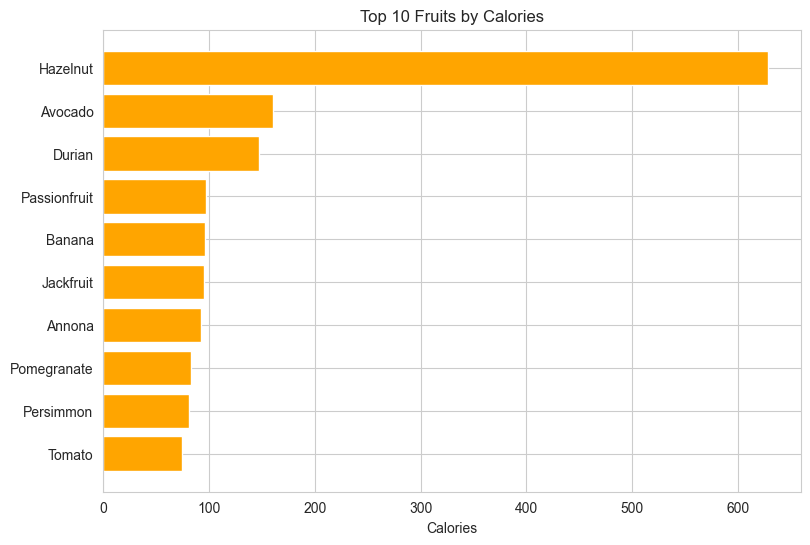

In [42]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_cal['name'], top_cal['calories'], color='orange')
ax.set_xlabel('Calories')
ax.set_title('Top 10 Fruits by Calories')
ax.invert_yaxis()


Text(0.5, 1.0, 'Sugar vs Calories')

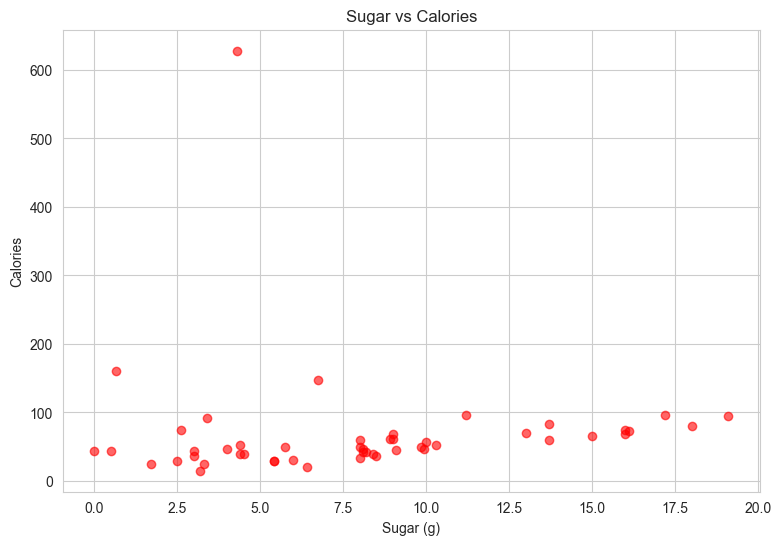

In [43]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df2['sugar'], df2['calories'], alpha=0.6, color='red')
ax.set_xlabel('Sugar (g)')
ax.set_ylabel('Calories')
ax.set_title('Sugar vs Calories')

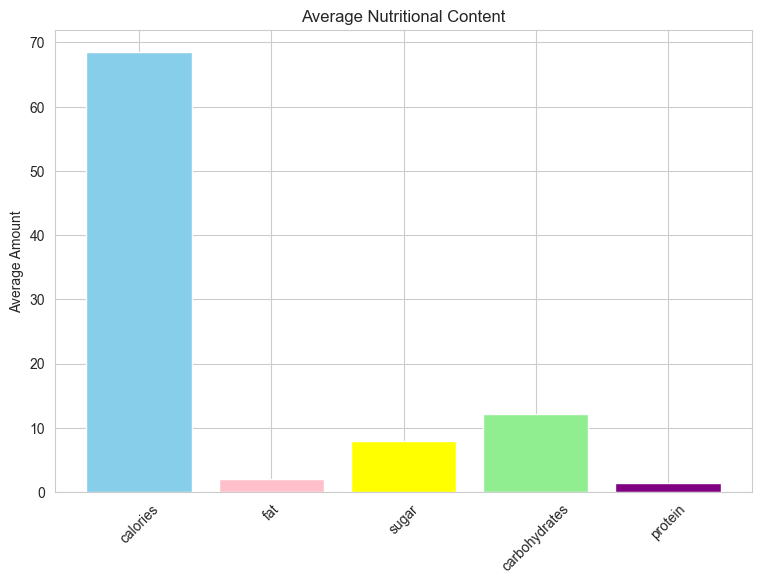

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))
avg_nutrition = df2[nutrition_cols].mean()
ax.bar(avg_nutrition.index, avg_nutrition.values, color=['skyblue', 'pink', 'yellow', 'lightgreen', 'purple'])
ax.set_ylabel('Average Amount')
ax.set_title('Average Nutritional Content')
ax.tick_params(axis='x', rotation=45)